# Klasifikasi Status Stunting Balita: Perbandingan Model dan Inovasi Pemodelan

**Tujuan.** Membangun model machine learning yang memprediksi status tinggi badan balita (sangat pendek, pendek, normal, tinggi) dari umur, jenis kelamin, dan tinggi badan.

**Cara menjalankan di Google Colab.** Jalankan sel dari atas ke bawah. Saat diminta, upload dua file: `data_balita.csv` dan `who_lhfa.csv`.

**Daftar isi**
1. Pemahaman data
2. Pembersihan data
3. Eksplorasi data (EDA)
4. Validasi label dengan standar WHO
5. Rekayasa fitur
6. Pembagian data dan baseline
7. Perbandingan model
8. Penyetelan hyperparameter
9. Evaluasi pada data uji
10. **Inovasi 1**: fitur berbasis pengetahuan WHO
11. **Inovasi 2**: klasifikasi ordinal (Frank & Hall)
12. **Inovasi 3**: prediksi sadar ketidakpastian (zona abu-abu)
13. **Inovasi 4**: uji ketahanan terhadap galat pengukuran
14. Interpretasi model dan analisis kesalahan
15. Simpan model dan contoh penggunaan
16. Kesimpulan

In [ ]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

DATA_CSV, WHO_CSV = "data_balita.csv", "who_lhfa.csv"
if not (os.path.exists(DATA_CSV) and os.path.exists(WHO_CSV)):
    from google.colab import files   # hanya ada di Colab
    print("Upload data_balita.csv dan who_lhfa.csv")
    files.upload()

## 1. Pemahaman data

Dataset berisi umur (bulan), jenis kelamin, tinggi badan (cm), dan status gizi balita. Mari lihat isinya.

In [ ]:
df_raw = pd.read_csv(DATA_CSV)
print("5 baris pertama:")
display(df_raw.head())
print("5 baris terakhir:")
display(df_raw.tail())
print("Bentuk data (baris, kolom):", df_raw.shape)

5 baris pertama:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
0,0,laki-laki,44.591973,stunted
1,0,laki-laki,56.705203,tinggi
2,0,laki-laki,46.863358,normal
3,0,laki-laki,47.508026,normal
4,0,laki-laki,42.743494,severely stunted


5 baris terakhir:


,Umur (bulan),Jenis Kelamin,Tinggi Badan (cm),Status Gizi
120994,60,perempuan,100.6,normal
120995,60,perempuan,98.3,stunted
120996,60,perempuan,121.3,normal
120997,60,perempuan,112.2,normal
120998,60,perempuan,109.8,normal


Bentuk data (baris, kolom): (120999, 4)


In [ ]:
print("Informasi kolom dan tipe data:")
df_raw.info()
print("\nStatistik deskriptif kolom numerik:")
display(df_raw.describe().round(2))
print("Statistik deskriptif kolom kategorikal:")
display(df_raw.describe(exclude="number"))

Informasi kolom dan tipe data:
<class 'pandas.DataFrame'>
RangeIndex: 120999 entries, 0 to 120998
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Umur (bulan)       120999 non-null  int64  
 1   Jenis Kelamin      120999 non-null  str    
 2   Tinggi Badan (cm)  120999 non-null  float64
 3   Status Gizi        120999 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 5.6 MB

Statistik deskriptif kolom numerik:


,Umur (bulan),Tinggi Badan (cm)
count,120999.00,120999.00
mean,30.17,88.66
std,17.58,17.30
min,0.00,40.01
25%,15.00,77.00
50%,30.00,89.80
75%,45.00,101.20
max,60.00,128.00


Statistik deskriptif kolom kategorikal:


,Jenis Kelamin,Status Gizi
count,120999,120999
unique,2,4
top,perempuan,normal
freq,61002,67755


In [ ]:
print("Nilai kosong per kolom:")
display(df_raw.isna().sum().to_frame("kosong"))
dup = df_raw.duplicated()
print(f"Baris duplikat: {dup.sum():,} ({dup.mean():.1%} dari seluruh data)")
for kol in df_raw.select_dtypes(exclude="number").columns:
    print(f"\nSebaran nilai '{kol}':")
    display(df_raw[kol].value_counts().to_frame("jumlah"))

Nilai kosong per kolom:


,kosong
Umur (bulan),0
Jenis Kelamin,0
Tinggi Badan (cm),0
Status Gizi,0


Baris duplikat: 81,574 (67.4% dari seluruh data)

Sebaran nilai 'Jenis Kelamin':


,jumlah
Jenis Kelamin,
perempuan,61002
laki-laki,59997



Sebaran nilai 'Status Gizi':


,jumlah
Status Gizi,
normal,67755
severely stunted,19869
tinggi,19560
stunted,13815


**Temuan awal.** Tidak ada nilai kosong, tetapi lebih dari separuh baris adalah duplikat. Tinggi badan memiliki belasan angka desimal,
yang tidak lazim untuk hasil pengukuran di lapangan. Ini petunjuk bahwa data dibuat dari simulasi. Kita akan menguji dugaan ini di bagian 4.

## 2. Pembersihan data

Langkah yang dilakukan:
- menyingkat nama kolom dan merapikan teks,
- mengubah status menjadi angka berurutan (0 = sangat pendek sampai 3 = tinggi), karena kelasnya memang berurutan,
- mengubah jenis kelamin menjadi 0/1,
- **membuang duplikat sebelum membagi data**, supaya baris yang sama tidak muncul di data latih sekaligus data uji.

In [ ]:
ORDER = ["severely stunted", "stunted", "normal", "tinggi"]          # urutan kelas: indeks 0..3
NAMA = ["Sangat pendek", "Pendek", "Normal", "Tinggi"]
WARNA = ["#C53030", "#C77700", "#2F855A", "#2B6CB0"]
JK_KODE = {"laki-laki": 0, "perempuan": 1}

df = df_raw.copy()
df.columns = ["umur", "jk", "tinggi", "label"]
df["jk"] = df["jk"].str.strip().str.lower()
df["label"] = df["label"].str.strip().str.lower()

n_awal = len(df)
df = df.dropna().drop_duplicates().reset_index(drop=True)
df["y"] = df["label"].map({k: i for i, k in enumerate(ORDER)})
df["jk_kode"] = df["jk"].map(JK_KODE)

print(f"Baris awal {n_awal:,} -> setelah dibersihkan {len(df):,} (duplikat dibuang {n_awal - len(df):,})")
display(df.head())
print("Statistik tinggi badan per kelas:")
display(df.groupby("label")["tinggi"].describe().loc[ORDER].round(1))

Baris awal 120,999 -> setelah dibersihkan 39,425 (duplikat dibuang 81,574)


,umur,jk,tinggi,label,y,jk_kode
0,0,laki-laki,44.591973,stunted,1,0
1,0,laki-laki,56.705203,tinggi,3,0
2,0,laki-laki,46.863358,normal,2,0
3,0,laki-laki,47.508026,normal,2,0
4,0,laki-laki,42.743494,severely stunted,0,0


Statistik tinggi badan per kelas:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
severely stunted,6520.0,70.4,16.0,40.0,56.5,73.4,84.3,95.9
stunted,4417.0,80.5,15.0,43.6,72.8,84.8,92.3,100.7
normal,21514.0,90.7,18.5,45.4,80.1,94.6,104.4,123.9
tinggi,6974.0,89.8,21.0,54.7,70.4,89.2,108.4,128.0


## 3. Eksplorasi data (EDA)

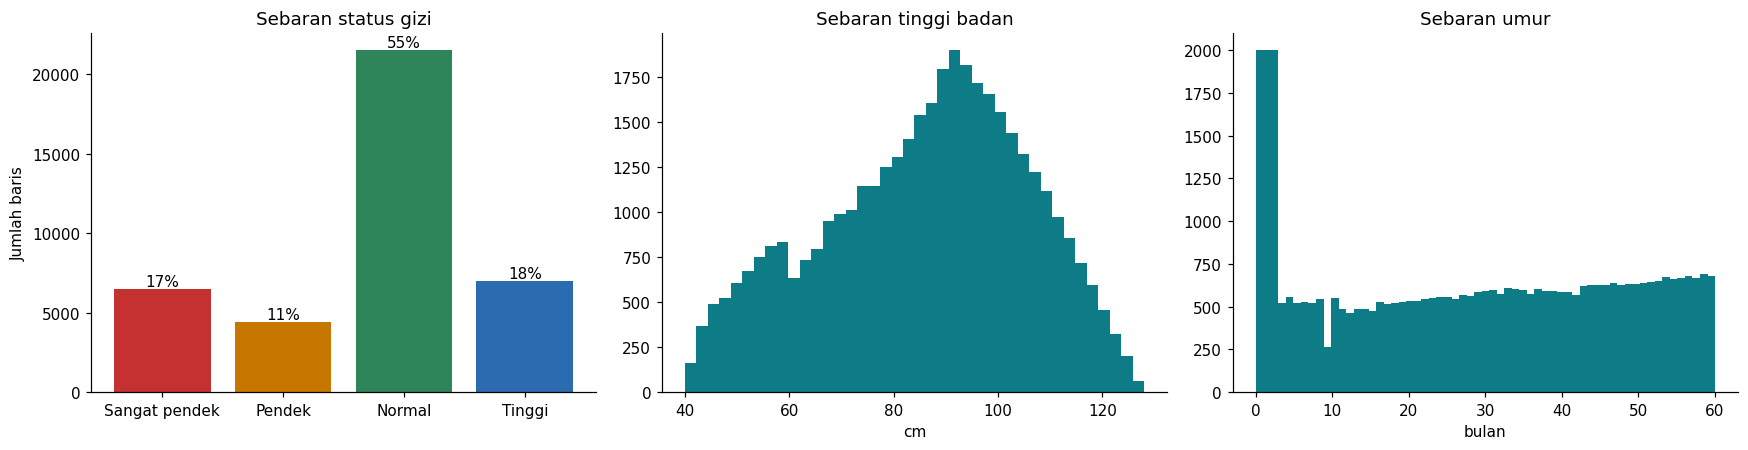

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
hitung = df["y"].value_counts().sort_index()
bars = ax[0].bar(NAMA, hitung.values, color=WARNA)
for b, v in zip(bars, hitung.values):
    ax[0].text(b.get_x() + b.get_width() / 2, v, f"{v / len(df):.0%}", ha="center", va="bottom")
ax[0].set_title("Sebaran status gizi"); ax[0].set_ylabel("Jumlah baris")
ax[1].hist(df["tinggi"], bins=40, color="#0E7C86"); ax[1].set_title("Sebaran tinggi badan"); ax[1].set_xlabel("cm")
ax[2].hist(df["umur"], bins=61, color="#0E7C86"); ax[2].set_title("Sebaran umur"); ax[2].set_xlabel("bulan")
plt.tight_layout(); plt.show()

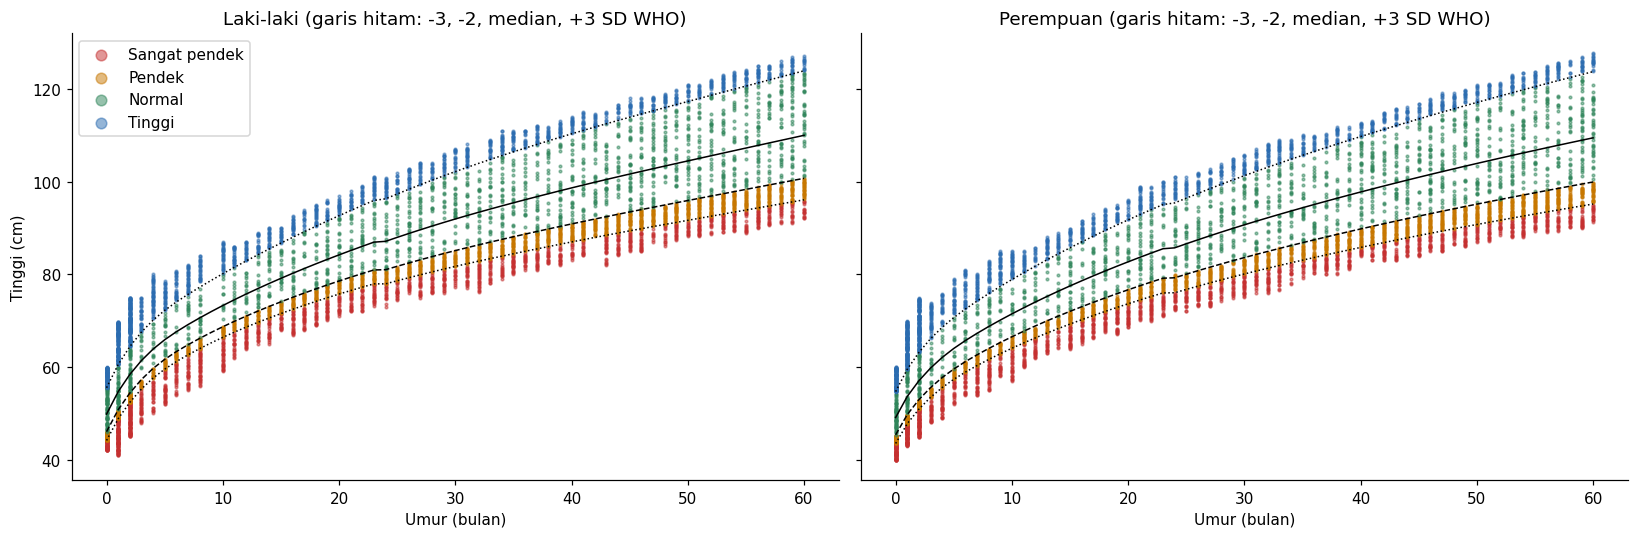

In [ ]:
who = pd.read_csv(WHO_CSV)   # tabel LMS WHO: jk, umur, L, M, S

fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for a, jk in zip(ax, ["laki-laki", "perempuan"]):
    d = df[df["jk"] == jk]
    for k in range(4):
        s = d[d["y"] == k]
        s = s.sample(min(1500, len(s)), random_state=SEED)
        a.scatter(s["umur"], s["tinggi"], s=3, alpha=.5, color=WARNA[k], label=NAMA[k])
    t = who[who["jk"] == jk].sort_values("umur")
    for zz, gaya in ((-3, ":"), (-2, "--"), (0, "-"), (3, ":")):
        a.plot(t["umur"], t["M"] * (1 + t["S"] * zz), color="black", lw=1, ls=gaya)
    a.set_title(f"{jk.capitalize()} (garis hitam: -3, -2, median, +3 SD WHO)")
    a.set_xlabel("Umur (bulan)")
ax[0].set_ylabel("Tinggi (cm)"); ax[0].legend(markerscale=4, loc="upper left")
plt.tight_layout(); plt.show()

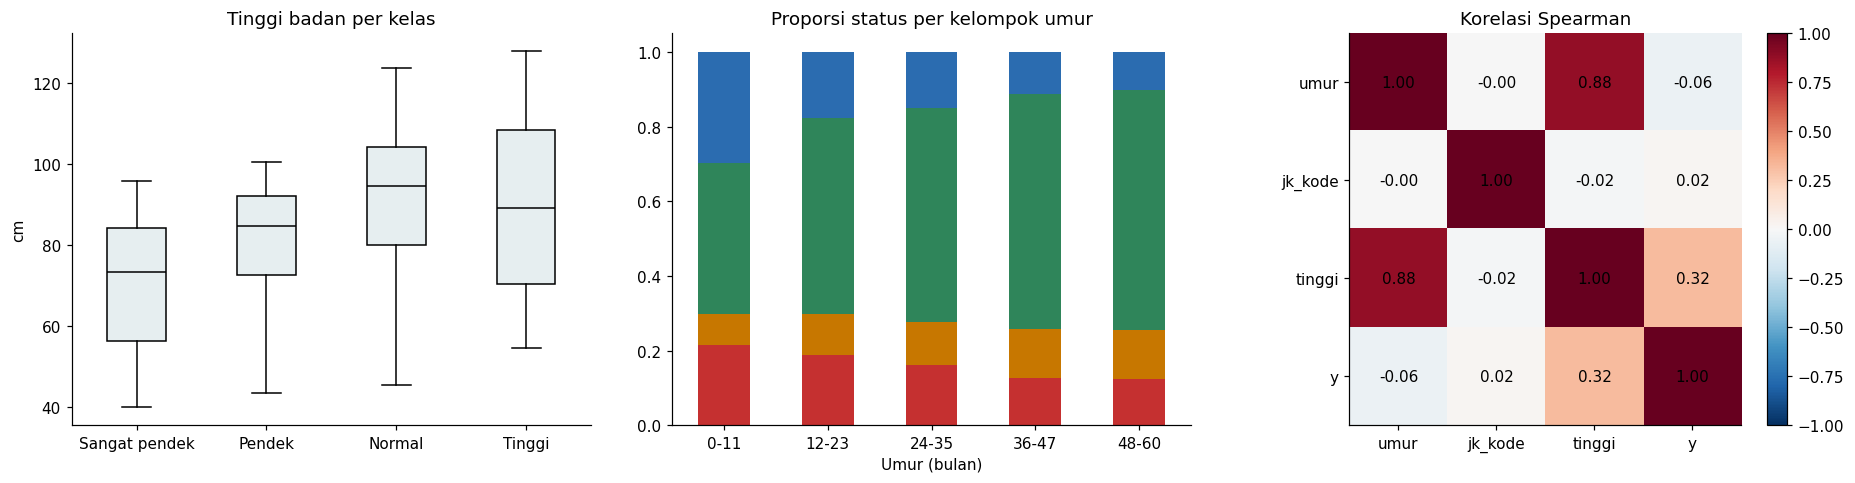

Proporsi status gizi menurut jenis kelamin:


label,severely stunted,stunted,normal,tinggi
jk,,,,
laki-laki,0.173,0.112,0.544,0.171
perempuan,0.158,0.112,0.548,0.183


In [ ]:
df["kelompok_umur"] = pd.cut(df["umur"], [-1, 11, 23, 35, 47, 60], labels=["0-11", "12-23", "24-35", "36-47", "48-60"])
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# 1) tinggi per kelas
ax[0].boxplot([df.loc[df["y"] == k, "tinggi"] for k in range(4)], labels=NAMA, patch_artist=True,
              boxprops=dict(facecolor="#E6EEF0"), medianprops=dict(color="black"))
ax[0].set_title("Tinggi badan per kelas"); ax[0].set_ylabel("cm")

# 2) proporsi kelas per kelompok umur
pr = pd.crosstab(df["kelompok_umur"], df["y"], normalize="index")
pr.plot(kind="bar", stacked=True, ax=ax[1], color=WARNA, legend=False)
ax[1].set_title("Proporsi status per kelompok umur"); ax[1].set_xlabel("Umur (bulan)"); ax[1].tick_params(axis="x", rotation=0)

# 3) korelasi Spearman
kor = df[["umur", "jk_kode", "tinggi", "y"]].corr(method="spearman")
im = ax[2].imshow(kor, cmap="RdBu_r", vmin=-1, vmax=1)
ax[2].set_xticks(range(4)); ax[2].set_xticklabels(kor.columns); ax[2].set_yticks(range(4)); ax[2].set_yticklabels(kor.columns)
for i in range(4):
    for j in range(4):
        ax[2].text(j, i, f"{kor.iloc[i, j]:.2f}", ha="center", va="center")
ax[2].set_title("Korelasi Spearman"); plt.colorbar(im, ax=ax[2], fraction=.046)
plt.tight_layout(); plt.show()

print("Proporsi status gizi menurut jenis kelamin:")
display(pd.crosstab(df["jk"], df["label"], normalize="index")[ORDER].round(3))

**Catatan EDA.** Tinggi badan sangat berkaitan dengan umur, sehingga menilai status hanya dari tinggi saja tidak cukup: tinggi 80 cm normal
untuk anak 18 bulan, tetapi sangat pendek untuk anak 48 bulan. Korelasi tinggi dengan status tampak rendah karena hubungannya
bergantung pada umur dan jenis kelamin, bukan hubungan linear sederhana. Inilah alasan model non-linear diperlukan.

## 4. Validasi label dengan standar WHO

Status stunting ditentukan dari Z-score tinggi menurut umur (TB/U):

`Z = ((tinggi / M) ** L - 1) / (S * L)`, dengan L = 1 untuk TB/U, dan M serta S dari tabel WHO menurut umur dan jenis kelamin.

Ambang (Permenkes No. 2 Tahun 2020): Z < -3 sangat pendek, -3 sampai < -2 pendek, -2 sampai +3 normal, Z > +3 tinggi.
Kita periksa seberapa cocok label dataset dengan aturan ini.

In [ ]:
def tambah_who(d):
    """Tambahkan M, S, dan Z-score TB/U ke tabel yang punya kolom umur, jk, tinggi."""
    m = d[["umur", "jk"]].merge(who, on=["jk", "umur"], how="left")
    out = d.copy()
    out["M"], out["S"] = m["M"].values, m["S"].values
    out["z"] = (out["tinggi"] / out["M"] - 1) / out["S"]          # L = 1
    return out

def kelas_dari_z(z):
    """Z-score -> indeks kelas 0..3 sesuai ambang WHO."""
    return np.select([z < -3, z < -2, z <= 3], [0, 1, 2], default=3)

df = tambah_who(df)
df["y_who"] = kelas_dari_z(df["z"].values)

cocok = (df["y"] == df["y_who"]).mean()
tak_wajar = int((df["z"].abs() > 6).sum())
print(f"Label dataset cocok dengan Z-score WHO : {cocok:.2%}")
print(f"Baris dengan |Z| > 6 (tidak wajar)     : {tak_wajar:,} ({tak_wajar / len(df):.1%})")
print("\nTabel silang (baris: label dataset, kolom: hasil rumus WHO):")
display(pd.crosstab(df["y"].map(dict(enumerate(NAMA))), df["y_who"].map(dict(enumerate(NAMA)))).loc[NAMA, NAMA])

Label dataset cocok dengan Z-score WHO : 99.51%
Baris dengan |Z| > 6 (tidak wajar)     : 938 (2.4%)

Tabel silang (baris: label dataset, kolom: hasil rumus WHO):


y_who,Sangat pendek,Pendek,Normal,Tinggi
y,,,,
Sangat pendek,6510,10,0,0
Pendek,55,4303,59,0
Normal,0,2,21449,63
Tinggi,0,0,3,6971


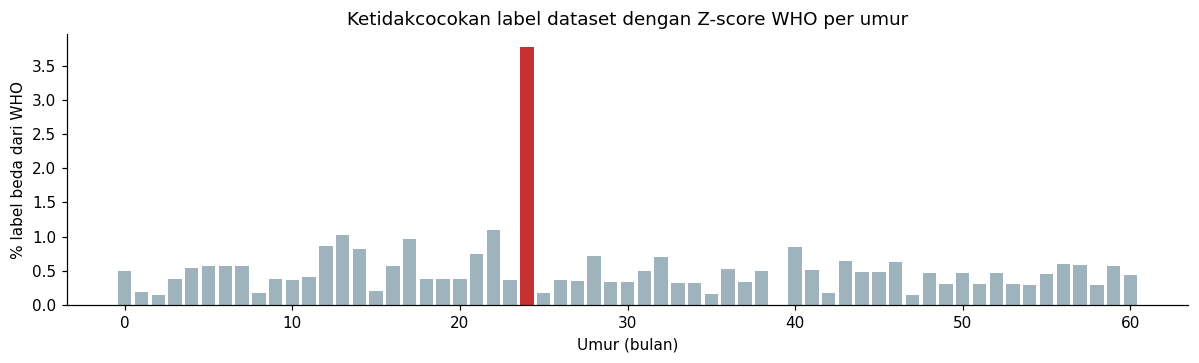

Umur 24 bulan: 3.8% label berbeda | umur lain rata-rata 0.5%


In [ ]:
df["beda"] = df["y"] != df["y_who"]
beda_umur = df.groupby("umur")["beda"].mean()
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(beda_umur.index, beda_umur.values * 100, color=np.where(beda_umur.index == 24, "#C53030", "#9FB3BC"))
ax.set_xlabel("Umur (bulan)"); ax.set_ylabel("% label beda dari WHO"); ax.set_title("Ketidakcocokan label dataset dengan Z-score WHO per umur")
plt.tight_layout(); plt.show()
print(f"Umur 24 bulan: {beda_umur[24]:.1%} label berbeda | umur lain rata-rata {beda_umur.drop(24).mean():.1%}")

**Temuan.** Ketidakcocokan label tidak merata: umur 24 bulan menonjol. Kemungkinan penyebabnya, WHO memakai panjang badan (diukur berbaring) sampai usia 23 bulan dan tinggi badan (diukur berdiri) mulai 24 bulan, dengan selisih sekitar 0,7 cm, dan dataset tampaknya mencampur kedua acuan pada umur 24. Ini penjelasan dugaan, bukan hasil yang dibuktikan. Dampaknya: prediksi model dan Z-score bisa berbeda pada anak berumur tepat 24 bulan.

**Kesimpulan bagian ini.** Label dataset hampir selalu sama dengan hasil rumus WHO, jadi label konsisten dengan standar.
Perbedaan kecil terjadi di dekat ambang (pembulatan tabel). Sebagian baris memiliki |Z| di atas 6, nilai yang tidak mungkin
pada anak sungguhan menurut kriteria WHO, yang menguatkan dugaan bahwa data ini simulasi.

Konsekuensinya penting: karena label dibuat dari rumus yang memakai umur, jenis kelamin, dan tinggi, akurasi tinggi pada
data ini **bukan bukti model menemukan pola baru**. Model pada dasarnya mempelajari ulang aturan WHO. Karena itu,
nilai tambah proyek ini terutama ada pada cara kita mengevaluasi dan memakai modelnya (bagian inovasi), bukan pada angka akurasi.

## 5. Rekayasa fitur

Selain fitur dasar (**Set A**: umur, jenis kelamin, tinggi), kita buat fitur berbasis pengetahuan WHO (**Set B**):
- `z`: Z-score TB/U,
- `selisih_median`: selisih tinggi anak dari median WHO (cm),
- `rasio_median`: tinggi anak dibagi median WHO.

Fitur ini dihitung hanya dari umur, jenis kelamin, tinggi, dan tabel WHO. Label tidak dipakai sama sekali, jadi tidak ada kebocoran data.

,umur,jk,tinggi,M,z,selisih_median,rasio_median,label
0,0,laki-laki,44.591973,49.8842,-2.795527,-5.292227,0.893910,stunted
1,0,laki-laki,56.705203,49.8842,3.603076,6.821003,1.136737,tinggi
2,0,laki-laki,46.863358,49.8842,-1.595707,-3.020842,0.939443,normal
3,0,laki-laki,47.508026,49.8842,-1.255173,-2.376174,0.952366,normal
4,0,laki-laki,42.743494,49.8842,-3.771954,-7.140706,0.856854,severely stunted


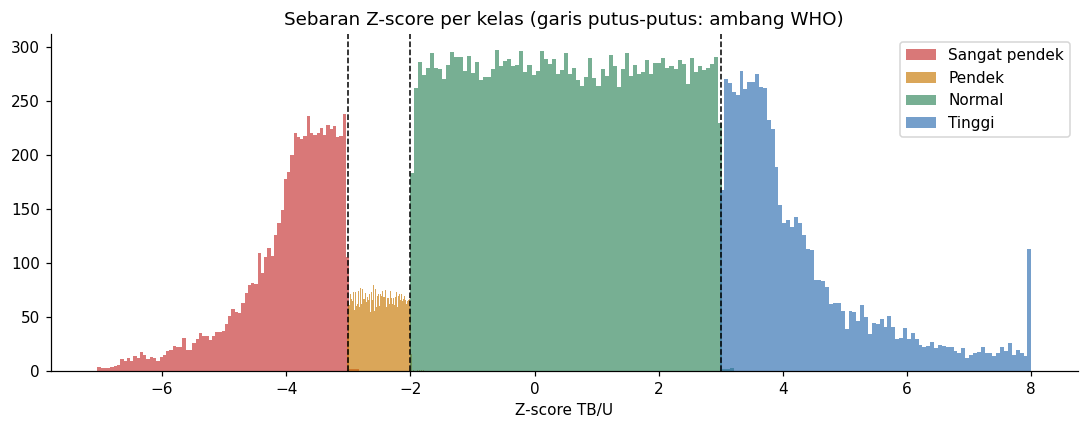

In [ ]:
df["selisih_median"] = df["tinggi"] - df["M"]
df["rasio_median"] = df["tinggi"] / df["M"]

FITUR_A = ["umur", "jk_kode", "tinggi"]
FITUR_B = FITUR_A + ["z", "selisih_median", "rasio_median"]

display(df[["umur", "jk", "tinggi", "M", "z", "selisih_median", "rasio_median", "label"]].head())

fig, ax = plt.subplots(figsize=(10, 4))
for k in range(4):
    ax.hist(df.loc[df["y"] == k, "z"].clip(-8, 8), bins=80, alpha=.65, color=WARNA[k], label=NAMA[k])
for t in (-3, -2, 3):
    ax.axvline(t, color="black", ls="--", lw=1)
ax.set_title("Sebaran Z-score per kelas (garis putus-putus: ambang WHO)"); ax.set_xlabel("Z-score TB/U"); ax.legend()
plt.tight_layout(); plt.show()

## 6. Pembagian data dan baseline

Data dibagi 80% latih dan 20% uji secara berstrata (proporsi kelas dijaga). **Pemilihan dan penyetelan model hanya memakai data latih
(dengan cross-validation)**. Data uji disentuh sekali di akhir untuk penilaian jujur.

Dua pembanding sebagai patokan: tebakan kelas terbanyak, dan aturan WHO murni (bukan machine learning).

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score, classification_report,
                             ConfusionMatrixDisplay, cohen_kappa_score)

tr_idx, te_idx = train_test_split(df.index, test_size=0.2, stratify=df["y"], random_state=SEED)
y_tr, y_te = df.loc[tr_idx, "y"], df.loc[te_idx, "y"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print(f"Data latih: {len(tr_idx):,} | data uji: {len(te_idx):,}")
display(pd.DataFrame({"latih": y_tr.value_counts(normalize=True).sort_index(),
                      "uji": y_te.value_counts(normalize=True).sort_index()}).set_index(pd.Index(NAMA)).round(3))

dummy = DummyClassifier(strategy="most_frequent").fit(df.loc[tr_idx, FITUR_A], y_tr)
p_dummy = dummy.predict(df.loc[te_idx, FITUR_A])
p_rule = df.loc[te_idx, "y_who"].values
baseline = pd.DataFrame({
    "Tebakan kelas terbanyak": [accuracy_score(y_te, p_dummy), f1_score(y_te, p_dummy, average="macro")],
    "Aturan WHO (bukan ML)":   [accuracy_score(y_te, p_rule),  f1_score(y_te, p_rule,  average="macro")],
}, index=["Akurasi", "F1-macro"]).T
display(baseline.round(4))

Data latih: 31,540 | data uji: 7,885


,latih,uji
Sangat pendek,0.165,0.165
Pendek,0.112,0.112
Normal,0.546,0.546
Tinggi,0.177,0.177


,Akurasi,F1-macro
Tebakan kelas terbanyak,0.5457,0.1765
Aturan WHO (bukan ML),0.9968,0.9955


## 7. Perbandingan model

Lima model dibandingkan dengan 5-fold cross-validation pada data latih, memakai fitur Set A. Metrik utama adalah **F1-macro**,
karena kelas tidak seimbang dan kita ingin kelas kecil (pendek) ikut dihitung adil.

,Akurasi,F1-macro,F1-macro (std),Balanced acc,Waktu (dtk)
Model,,,,,
KNN,0.9890,0.9845,0.0020,0.9845,0.3076
Random Forest,0.9873,0.9822,0.0022,0.9821,6.0830
Gradient Boosting,0.9799,0.9717,0.0032,0.9724,6.7573
Decision Tree,0.9475,0.9251,0.0039,0.9207,0.1889
Logistic Regression,0.6968,0.5489,0.0046,0.5607,0.3711


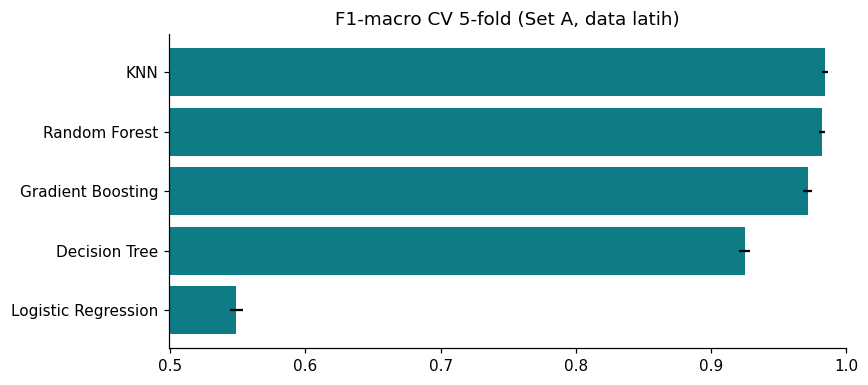

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

def model_dasar():
    return {
        "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
        "Decision Tree": DecisionTreeClassifier(max_depth=12, random_state=SEED),
        "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=7, weights="distance")),
        "Random Forest": RandomForestClassifier(n_estimators=100, min_samples_leaf=3, random_state=SEED, n_jobs=-1),
        "Gradient Boosting": HistGradientBoostingClassifier(random_state=SEED),
    }

def bandingkan(fitur):
    baris = []
    for nama, m in model_dasar().items():
        t0 = time.time()
        sk = cross_validate(m, df.loc[tr_idx, fitur], y_tr, cv=cv,
                            scoring=["accuracy", "f1_macro", "balanced_accuracy"], n_jobs=-1)
        baris.append({"Model": nama,
                      "Akurasi": sk["test_accuracy"].mean(),
                      "F1-macro": sk["test_f1_macro"].mean(), "F1-macro (std)": sk["test_f1_macro"].std(),
                      "Balanced acc": sk["test_balanced_accuracy"].mean(),
                      "Waktu (dtk)": time.time() - t0})
    return pd.DataFrame(baris).set_index("Model")

hasil_A = bandingkan(FITUR_A)
display(hasil_A.sort_values("F1-macro", ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8, 3.6))
u = hasil_A.sort_values("F1-macro")
ax.barh(u.index, u["F1-macro"], xerr=u["F1-macro (std)"], color="#0E7C86")
ax.set_xlim(max(0, u["F1-macro"].min() - .05), 1.0); ax.set_title("F1-macro CV 5-fold (Set A, data latih)")
plt.tight_layout(); plt.show()

Model linear (Logistic Regression) jauh tertinggal karena batas antar kelas bergantung pada umur secara non-linear.
Model berbasis pohon dan tetangga terdekat menangkap pola ini jauh lebih baik.

## 8. Penyetelan hyperparameter

Tiga model terbaik disetel dengan `RandomizedSearchCV` (3-fold, skor F1-macro, hanya pada data latih). Agar adil, model hasil penyetelan lalu dinilai
ulang dengan 5-fold yang sama seperti sebelum penyetelan. Angka "sesudah" sedikit optimistis karena parameternya dipilih dari data yang sama.

In [ ]:
ruang = {
    "Random Forest": (RandomForestClassifier(random_state=SEED, n_jobs=1),
        {"n_estimators": [100, 200, 300], "max_depth": [None, 10, 20, 30],
         "min_samples_leaf": [1, 2, 3, 5], "max_features": [1.0, "sqrt"]}),
    "Gradient Boosting": (HistGradientBoostingClassifier(random_state=SEED),
        {"learning_rate": [0.03, 0.05, 0.1, 0.2], "max_leaf_nodes": [15, 31, 63],
         "max_iter": [100, 200, 300], "min_samples_leaf": [10, 20, 40], "l2_regularization": [0, 0.1, 1.0]}),
    "KNN": (Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier())]),
        {"knn__n_neighbors": [3, 5, 7, 9, 11, 15], "knn__weights": ["uniform", "distance"]}),
}
X_tr_A = df.loc[tr_idx, FITUR_A]
tuned, ringkas_tuning = {}, []
for nama, (est, grid) in ruang.items():
    t0 = time.time()
    rs = RandomizedSearchCV(est, grid, n_iter=10, cv=3, scoring="f1_macro", random_state=SEED, n_jobs=-1)
    rs.fit(X_tr_A, y_tr)
    tuned[nama] = rs.best_estimator_
    sk = cross_validate(rs.best_estimator_, X_tr_A, y_tr, cv=cv, scoring="f1_macro", n_jobs=-1)
    ringkas_tuning.append({"Model": nama, "F1-macro sebelum (5-fold)": hasil_A.loc[nama, "F1-macro"],
                           "F1-macro sesudah (5-fold)": sk["test_score"].mean(),
                           "Waktu pencarian (dtk)": time.time() - t0, "Parameter terbaik": rs.best_params_})
tabel_tuning = pd.DataFrame(ringkas_tuning).set_index("Model")
display(tabel_tuning.round(4))
perubahan = tabel_tuning["F1-macro sesudah (5-fold)"] - tabel_tuning["F1-macro sebelum (5-fold)"]
print("Perubahan F1-macro akibat penyetelan:", {k: f"{v:+.4f}" for k, v in perubahan.items()})

,F1-macro sebelum (5-fold),F1-macro sesudah (5-fold),Waktu pencarian (dtk),Parameter terbaik
Model,,,,
Random Forest,0.9822,0.9811,101.5946,"{'n_estimators': 200, 'min_samples_leaf': 5, '..."
Gradient Boosting,0.9717,0.9737,77.0355,"{'min_samples_leaf': 20, 'max_leaf_nodes': 63,..."
KNN,0.9845,0.9845,2.6858,"{'knn__weights': 'distance', 'knn__n_neighbors..."


Perubahan F1-macro akibat penyetelan: {'Random Forest': '-0.0011', 'Gradient Boosting': '+0.0020', 'KNN': '+0.0000'}


**Catatan.** Penyetelan hampir tidak mengubah hasil: perubahan F1-macro di bawah 0,003, setara dengan simpangan baku antar-fold. Wajar, karena masalahnya sudah hampir terpecahkan oleh model bawaan. Ini bukan kegagalan penyetelan, melainkan tanda bahwa ruang perbaikan memang sempit.

## 9. Evaluasi pada data uji

Model hasil penyetelan dinilai pada data uji yang belum pernah dipakai untuk memilih apa pun.
Selain akurasi dan F1, kita pakai **quadratic weighted kappa (QWK)** dan **galat ordinal rata-rata**, karena kelasnya berurutan:
salah menebak "sangat pendek" sebagai "tinggi" jauh lebih buruk daripada sebagai "pendek".

,Akurasi,F1-macro,Balanced acc,QWK,Galat ordinal rata-rata,Salah >= 2 tingkat
Random Forest,0.9890,0.9841,0.9847,0.9937,0.0110,0.0
Gradient Boosting,0.9839,0.9788,0.9812,0.9908,0.0161,0.0
KNN,0.9896,0.9855,0.9859,0.9941,0.0104,0.0


Model terbaik menurut CV 5-fold pada data latih: KNN


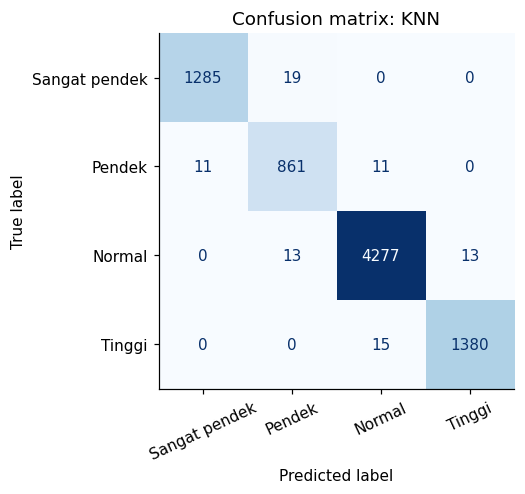

               precision    recall  f1-score   support

Sangat pendek      0.992     0.985     0.988      1304
       Pendek      0.964     0.975     0.970       883
       Normal      0.994     0.994     0.994      4303
       Tinggi      0.991     0.989     0.990      1395

     accuracy                          0.990      7885
    macro avg      0.985     0.986     0.985      7885
 weighted avg      0.990     0.990     0.990      7885



In [ ]:
def metrik_ordinal(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    d = np.abs(y_pred - y_true)
    return {"Akurasi": accuracy_score(y_true, y_pred),
            "F1-macro": f1_score(y_true, y_pred, average="macro"),
            "Balanced acc": balanced_accuracy_score(y_true, y_pred),
            "QWK": cohen_kappa_score(y_true, y_pred, weights="quadratic"),
            "Galat ordinal rata-rata": d.mean(),
            "Salah >= 2 tingkat": int((d >= 2).sum())}

X_te_A = df.loc[te_idx, FITUR_A]
pred_uji = {n: m.predict(X_te_A) for n, m in tuned.items()}
hasil_uji = pd.DataFrame({n: metrik_ordinal(y_te, p) for n, p in pred_uji.items()}).T
display(hasil_uji.round(4))

best_name = tabel_tuning["F1-macro sesudah (5-fold)"].idxmax()
best_model = tuned[best_name]
print("Model terbaik menurut CV 5-fold pada data latih:", best_name)

fig, ax = plt.subplots(figsize=(5.5, 4.6))
ConfusionMatrixDisplay.from_predictions(y_te, pred_uji[best_name], labels=range(4), display_labels=NAMA,
                                        ax=ax, cmap="Blues", xticks_rotation=25, colorbar=False)
ax.set_title(f"Confusion matrix: {best_name}"); plt.tight_layout(); plt.show()
print(classification_report(y_te, pred_uji[best_name], target_names=NAMA, digits=3))

## 10. fitur berbasis pengetahuan WHO

**Gagasan.** Alih-alih membiarkan model menebak hubungan umur dan tinggi dari nol, kita beri ia fitur hasil pengetahuan domain
(Z-score, selisih dari median, rasio terhadap median). Kita bandingkan Set A (mentah) dengan Set B (dengan fitur WHO) pada model yang sama.

,F1-macro Set A,F1-macro Set B,Selisih
Model,,,
Logistic Regression,0.5489,0.9869,0.4380
Decision Tree,0.9251,0.9979,0.0729
KNN,0.9845,0.9898,0.0053
Random Forest,0.9822,0.9982,0.0159
Gradient Boosting,0.9717,0.9955,0.0238


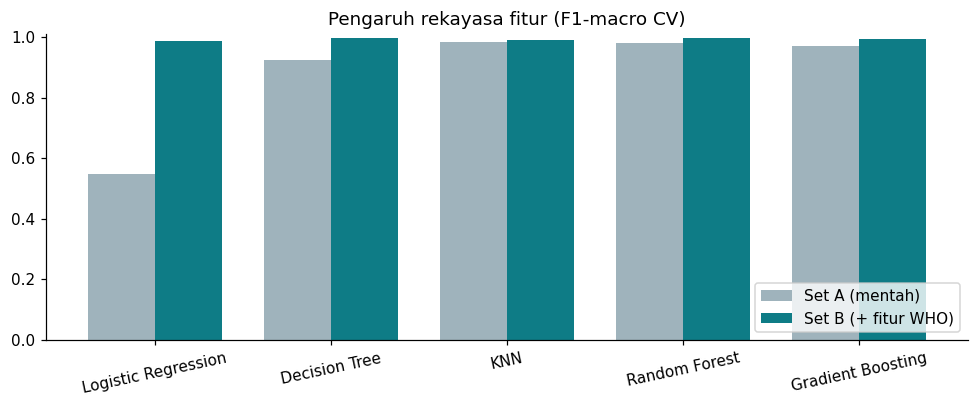

Pembanding, aturan WHO murni pada data latih: akurasi 0.9947 | F1-macro 0.9927
Peningkatan terbesar: Logistic Regression (+0.438 F1-macro).
Model paling sederhana (Logistic Regression): 0.549 -> 0.987 setelah diberi fitur WHO.


In [ ]:
hasil_B = bandingkan(FITUR_B)
banding = pd.DataFrame({"F1-macro Set A": hasil_A["F1-macro"], "F1-macro Set B": hasil_B["F1-macro"]})
banding["Selisih"] = banding["F1-macro Set B"] - banding["F1-macro Set A"]
display(banding.round(4))

x = np.arange(len(banding)); w = .38
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(x - w / 2, banding["F1-macro Set A"], w, label="Set A (mentah)", color="#9FB3BC")
ax.bar(x + w / 2, banding["F1-macro Set B"], w, label="Set B (+ fitur WHO)", color="#0E7C86")
ax.set_xticks(x); ax.set_xticklabels(banding.index, rotation=12); ax.set_ylim(max(0, banding.min().min() - .05), 1.01)
ax.set_title("Pengaruh rekayasa fitur (F1-macro CV)"); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

p_rule_tr = df.loc[tr_idx, "y_who"].values
print(f"Pembanding, aturan WHO murni pada data latih: akurasi {accuracy_score(y_tr, p_rule_tr):.4f} | F1-macro {f1_score(y_tr, p_rule_tr, average='macro'):.4f}")
terbesar = banding["Selisih"].idxmax()
print(f"Peningkatan terbesar: {terbesar} (+{banding.loc[terbesar, 'Selisih']:.3f} F1-macro).")
print(f"Model paling sederhana (Logistic Regression): {banding.loc['Logistic Regression', 'F1-macro Set A']:.3f} -> "
      f"{banding.loc['Logistic Regression', 'F1-macro Set B']:.3f} setelah diberi fitur WHO.")

**Cara membaca.** Keuntungan terbesar ada pada model sederhana: dengan Z-score, Logistic Regression melompat dari sekitar 0,55 ke sekitar 0,99,
karena Z-score pada dasarnya adalah aturan pelabelan itu sendiri. Model yang sudah kuat sejak Set A (KNN) hanya naik tipis.
Pesannya: pengetahuan domain bisa menggantikan kompleksitas model.

Dua catatan agar tidak salah tafsir. Pertama, hasil Set B adalah batas atas yang mudah dicapai karena fiturnya setara dengan label, bukan bukti model hebat.
Kedua, bila angka Set B melampaui aturan WHO murni (lihat baris pembanding di atas), penyebabnya kemungkinan label dataset sedikit menyimpang dari
tabel WHO di dekat ambang dan model mempelajari penyimpangan itu. Itu keunggulan terhadap dataset ini, bukan terhadap kebenaran klinis.

## 11. klasifikasi ordinal (Frank & Hall)

**Gagasan.** Kelas status gizi berurutan: sangat pendek < pendek < normal < tinggi. Pendekatan Frank & Hall memecah masalah menjadi
tiga pertanyaan biner ("apakah lebih tinggi dari sangat pendek?", "... dari pendek?", "... dari normal?"), lalu menggabungkan
probabilitasnya. Dengan begitu model memanfaatkan urutan kelas. Kita bandingkan dengan klasifikasi multikelas biasa memakai metrik ordinal.

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin, clone

class OrdinalFrankHall(BaseEstimator, ClassifierMixin):
    """Klasifikasi ordinal: latih K-1 model biner untuk P(y > k), lalu gabungkan menjadi probabilitas tiap kelas."""
    def __init__(self, base=None):
        self.base = base
    def fit(self, X, y):
        self.classes_ = np.sort(np.unique(y))
        self.models_ = [clone(self.base).fit(X, (np.asarray(y) > k).astype(int)) for k in self.classes_[:-1]]
        return self
    def predict_proba(self, X):
        gt = np.column_stack([m.predict_proba(X)[:, 1] for m in self.models_])   # P(y > k)
        P = np.empty((len(gt), len(self.classes_)))
        P[:, 0] = 1 - gt[:, 0]
        for j in range(1, gt.shape[1]):
            P[:, j] = gt[:, j - 1] - gt[:, j]
        P[:, -1] = gt[:, -1]
        P = np.clip(P, 0, None)
        return P / P.sum(axis=1, keepdims=True)
    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

baris_ord = {}
for nama in (best_name, "Random Forest"):
    if f"{nama} - multikelas" in baris_ord:
        continue
    base = tuned[nama]
    pred_multi = pred_uji[nama]
    pred_ord = OrdinalFrankHall(base=clone(base)).fit(X_tr_A, y_tr).predict(X_te_A)
    baris_ord[f"{nama} - multikelas"] = metrik_ordinal(y_te, pred_multi)
    baris_ord[f"{nama} - ordinal"] = metrik_ordinal(y_te, pred_ord)
banding_ord = pd.DataFrame(baris_ord).T
display(banding_ord.round(4))
selisih = np.abs(pred_uji[best_name] - y_te.values)
print(f"Kesalahan model {best_name}: {int((selisih == 1).sum())} bergeser 1 tingkat, {int((selisih >= 2).sum())} bergeser 2 tingkat atau lebih.")

,Akurasi,F1-macro,Balanced acc,QWK,Galat ordinal rata-rata,Salah >= 2 tingkat
KNN - multikelas,0.9896,0.9855,0.9859,0.9941,0.0104,0.0
KNN - ordinal,0.9896,0.9855,0.9859,0.9941,0.0104,0.0
Random Forest - multikelas,0.9890,0.9841,0.9847,0.9937,0.0110,0.0
Random Forest - ordinal,0.9887,0.9837,0.9843,0.9936,0.0113,0.0


Kesalahan model KNN: 82 bergeser 1 tingkat, 0 bergeser 2 tingkat atau lebih.


**Cara membaca.** Bandingkan baris "multikelas" dan "ordinal" untuk tiap model di tabel. Pada data ini semua kesalahan hanya bergeser ke kelas tetangga
(tidak ada yang meloncat dua tingkat atau lebih), sehingga metrik peka-urutan nyaris tidak punya hal untuk dibedakan. Ini hasil negatif yang jujur:
pada data simulasi yang bersih ini, pendekatan ordinal tidak memberi keuntungan terukur. Nilainya baru mungkin terlihat pada data lapangan yang berisik,
tempat kesalahan besar lebih mungkin terjadi.

## 12. prediksi sadar ketidakpastian (zona abu-abu)

**Gagasan.** Di dunia nyata, lebih baik model berkata "saya tidak yakin, ukur ulang" daripada memaksakan jawaban.
Kita pakai probabilitas model: bila keyakinan tertinggi di bawah ambang τ, kasus ditandai **zona abu-abu** dan diminta diukur ulang.
Kita ukur: berapa kasus yang ditandai (1 - coverage), seberapa naik akurasi pada kasus yang diprediksi, dan seberapa banyak kesalahan yang tertangkap.

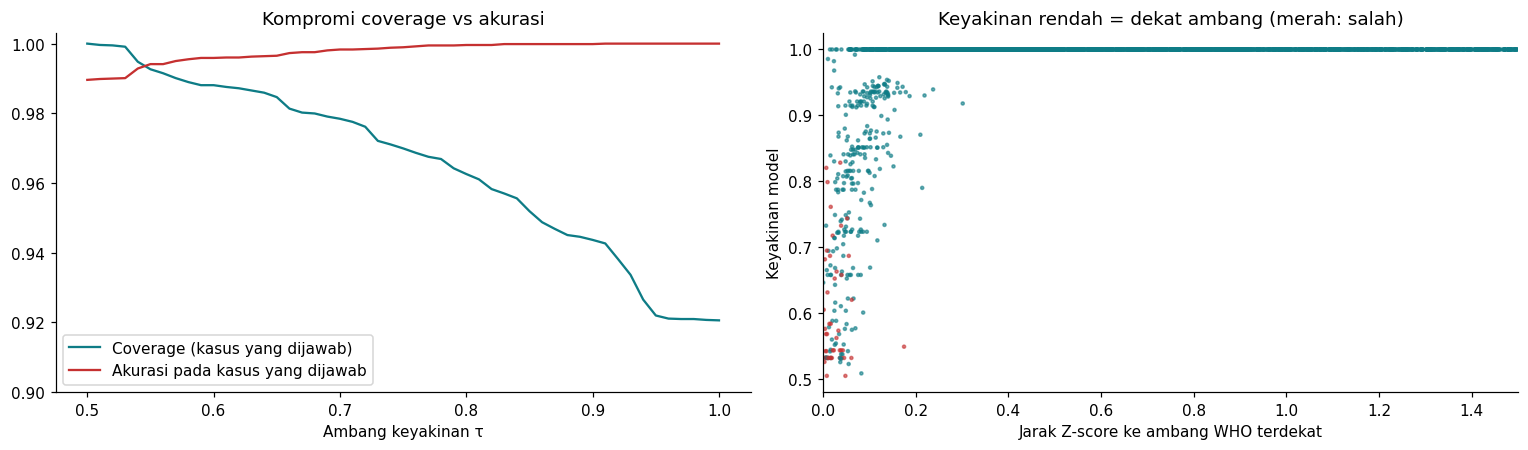

,Kasus ditandai abu-abu,Akurasi kasus dijawab,Kesalahan tertangkap
τ,,,
0.60,0.0119,0.9959,0.6098
0.70,0.0216,0.9983,0.8415
0.80,0.0374,0.9996,0.9634
0.90,0.0563,0.9999,0.9878
0.95,0.0780,1.0000,1.0000


Akurasi tanpa zona abu-abu: 0.9896
Median jarak ke ambang: kasus salah 0.021 | kasus benar 0.914 (satuan Z-score)


In [ ]:
proba = best_model.predict_proba(X_te_A)
pred = proba.argmax(axis=1)
conf = proba.max(axis=1)
benar = (pred == y_te.values)

# jarak Z-score ke ambang WHO terdekat (makin kecil = makin dekat batas)
z_te = df.loc[te_idx, "z"].values
dz = np.min(np.abs(z_te[:, None] - np.array([-3, -2, 3])[None, :]), axis=1)

taus = np.round(np.arange(0.50, 1.0001, 0.01), 2)
cov = np.array([(conf >= t).mean() for t in taus])
akr = np.array([benar[conf >= t].mean() if (conf >= t).any() else np.nan for t in taus])

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
ax[0].plot(taus, cov, label="Coverage (kasus yang dijawab)", color="#0E7C86")
ax[0].plot(taus, akr, label="Akurasi pada kasus yang dijawab", color="#C53030")
ax[0].set_xlabel("Ambang keyakinan τ"); ax[0].set_ylim(.9, 1.003); ax[0].legend(); ax[0].set_title("Kompromi coverage vs akurasi")
sampel = np.random.default_rng(SEED).choice(len(conf), 4000, replace=False)
ax[1].scatter(dz[sampel], conf[sampel], s=4, c=np.where(benar[sampel], "#0E7C86", "#C53030"), alpha=.6)
ax[1].set_xlim(0, 1.5); ax[1].set_xlabel("Jarak Z-score ke ambang WHO terdekat"); ax[1].set_ylabel("Keyakinan model")
ax[1].set_title("Keyakinan rendah = dekat ambang (merah: salah)")
plt.tight_layout(); plt.show()

baris = []
for t in (0.6, 0.7, 0.8, 0.9, 0.95):
    jawab = conf >= t
    salah = ~benar
    baris.append({"τ": t, "Kasus ditandai abu-abu": 1 - jawab.mean(),
                  "Akurasi kasus dijawab": benar[jawab].mean(),
                  "Kesalahan tertangkap": (salah & ~jawab).sum() / max(salah.sum(), 1)})
tabel_abu = pd.DataFrame(baris).set_index("τ")
display(tabel_abu.round(4))
print(f"Akurasi tanpa zona abu-abu: {benar.mean():.4f}")
print(f"Median jarak ke ambang: kasus salah {np.median(dz[~benar]):.3f} | kasus benar {np.median(dz[benar]):.3f} (satuan Z-score)")
TAU = 0.80

**Versi dengan jaminan statistik: conformal prediction.** Ambang τ di atas dipilih manual. Dengan *split conformal prediction*, model mengeluarkan
**himpunan kelas** (bukan satu kelas) dengan jaminan: kelas sebenarnya masuk dalam himpunan pada setidaknya (1 - α) kasus. Himpunan berisi lebih dari satu kelas,
atau kosong, berarti kasus ambigu (zona abu-abu). Kita kalibrasi pada sebagian data latih, lalu uji liputannya pada data uji.

In [ ]:
fit_idx, cal_idx = train_test_split(tr_idx, test_size=0.25, stratify=y_tr, random_state=SEED)
m_conf = clone(best_model).fit(df.loc[fit_idx, FITUR_A], df.loc[fit_idx, "y"])
y_cal = df.loc[cal_idx, "y"].values
p_cal = m_conf.predict_proba(df.loc[cal_idx, FITUR_A])
skor_cal = 1 - p_cal[np.arange(len(y_cal)), y_cal]          # skor non-konformitas: 1 - P(kelas benar)
p_uji = m_conf.predict_proba(X_te_A)

baris = []
for alpha in (0.10, 0.05, 0.01):
    n = len(skor_cal)
    q = np.quantile(skor_cal, min(1.0, np.ceil((n + 1) * (1 - alpha)) / n), method="higher")
    himpunan = (1 - p_uji) <= q                              # kelas yang masuk himpunan prediksi
    ukuran = himpunan.sum(axis=1)
    baris.append({"α": alpha, "Target coverage": 1 - alpha,
                  "Coverage di data uji": himpunan[np.arange(len(y_te)), y_te.values].mean(),
                  "Rata-rata ukuran himpunan": ukuran.mean(),
                  "Kasus ambigu (bukan tepat 1 kelas)": (ukuran != 1).mean()})
tabel_conf = pd.DataFrame(baris).set_index("α")
display(tabel_conf.round(4))
print("Coverage di data uji seharusnya mendekati atau di atas target. Kasus ambigu = kasus yang sebaiknya diukur ulang.")

,Target coverage,Coverage di data uji,Rata-rata ukuran himpunan,Kasus ambigu (bukan tepat 1 kelas)
α,,,,
0.10,0.90,0.8942,0.8942,0.1058
0.05,0.95,0.9458,0.9462,0.0538
0.01,0.99,0.9887,1.0016,0.0016


Coverage di data uji seharusnya mendekati atau di atas target. Kasus ambigu = kasus yang sebaiknya diukur ulang.


**Cara membaca.** Kesalahan model hampir seluruhnya terjadi pada anak yang Z-score-nya berada sangat dekat ambang (jarak kecil),
dan di sanalah keyakinan model rendah. Artinya, tanda "zona abu-abu" menunjuk tepat ke kasus yang memang meragukan.
Dalam praktik posyandu, selisih pengukuran beberapa milimeter saja bisa menggeser anak melewati ambang, jadi meminta ukur ulang
pada kasus ini lebih berguna daripada mengejar akurasi 100%.

Pada conformal prediction, periksa apakah coverage di data uji mendekati atau melampaui target (1 - α). Selisih kecil (sekitar satu poin persen atau kurang) wajar pada data uji yang terbatas, karena jaminan conformal berlaku rata-rata. Kolom kasus ambigu menunjukkan berapa banyak anak yang sebaiknya diukur ulang.

## 13. Uji ketahanan terhadap galat pengukuran

**Gagasan.** Data latih tidak punya galat pengukuran, padahal di lapangan tinggi badan sering meleset 0,5 sampai 1 cm. Kita simulasikan:
tinggi pada data uji ditambah noise acak (sigma 0 sampai 2 cm), sedangkan label tetap berdasar tinggi sebenarnya.
Kita bandingkan tiga pendekatan: (1) model standar, (2) model yang dilatih dengan data bernoise (augmentasi), dan (3) aturan WHO murni.

Pendekatan,Aturan WHO murni,Model + augmentasi noise,Model standar
sigma (cm),,,
0.00,0.9968,0.9679,0.9896
0.25,0.9798,0.9645,0.9768
0.50,0.9578,0.9469,0.9559
1.00,0.9218,0.9157,0.9209
1.50,0.8728,0.8692,0.8715
2.00,0.8370,0.8355,0.8367


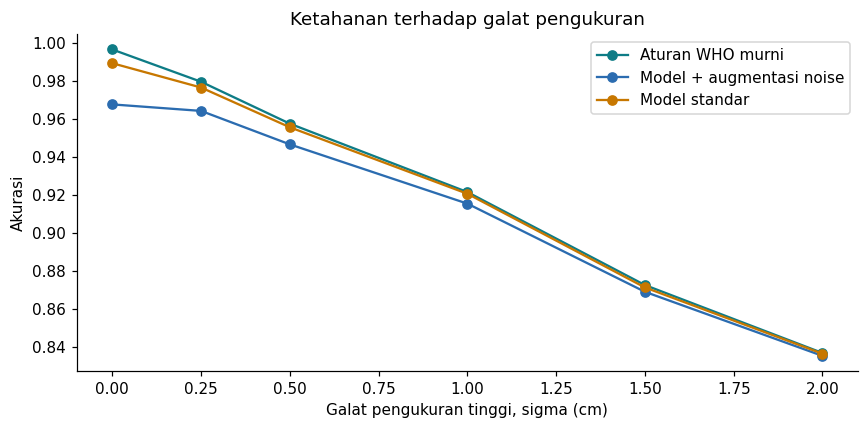

Augmentasi noise mengalahkan model standar pada sigma: tidak ada
Selisih akurasi terbesar antara model standar dan aturan WHO murni: 0.0072
Akurasi turun dari 0.997 (tanpa noise) menjadi sekitar 0.922 pada galat 1 cm dan 0.837 pada galat 2 cm.


In [ ]:
rng = np.random.default_rng(SEED)
tr = df.loc[tr_idx]
aug = pd.concat([tr] + [tr.assign(tinggi=tr["tinggi"] + rng.normal(0, s, len(tr))) for s in (0.25, 0.5, 1.0)], ignore_index=True)
model_aug = clone(best_model).fit(aug[FITUR_A], aug["y"])

te = df.loc[te_idx, ["umur", "jk", "jk_kode", "tinggi", "y"]].copy()
sigmas = [0, 0.25, 0.5, 1.0, 1.5, 2.0]
baris = []
for s in sigmas:
    r = np.random.default_rng(SEED + int(s * 100))
    tn = te.assign(tinggi=te["tinggi"] + r.normal(0, s, len(te)))
    p_std = best_model.predict(tn[FITUR_A])
    p_aug = model_aug.predict(tn[FITUR_A])
    p_rule = kelas_dari_z(tambah_who(tn)["z"].values)
    for nama, p in (("Model standar", p_std), ("Model + augmentasi noise", p_aug), ("Aturan WHO murni", p_rule)):
        baris.append({"sigma (cm)": s, "Pendekatan": nama, "Akurasi": accuracy_score(te["y"], p),
                      "F1-macro": f1_score(te["y"], p, average="macro")})
noise = pd.DataFrame(baris)
tabel_noise = noise.pivot(index="sigma (cm)", columns="Pendekatan", values="Akurasi")
display(tabel_noise.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
for kolom, warna in zip(tabel_noise.columns, ["#0E7C86", "#2B6CB0", "#C77700"]):
    ax.plot(tabel_noise.index, tabel_noise[kolom], marker="o", label=kolom, color=warna)
ax.set_xlabel("Galat pengukuran tinggi, sigma (cm)"); ax.set_ylabel("Akurasi")
ax.set_title("Ketahanan terhadap galat pengukuran"); ax.legend()
plt.tight_layout(); plt.show()
std_, aug_, rule_ = tabel_noise["Model standar"], tabel_noise["Model + augmentasi noise"], tabel_noise["Aturan WHO murni"]
lebih = [float(sg) for sg in tabel_noise.index if aug_[sg] > std_[sg]]
print("Augmentasi noise mengalahkan model standar pada sigma:", lebih if lebih else "tidak ada")
print(f"Selisih akurasi terbesar antara model standar dan aturan WHO murni: {(std_ - rule_).abs().max():.4f}")
print(f"Akurasi turun dari {tabel_noise.iloc[0].max():.3f} (tanpa noise) menjadi sekitar "
      f"{tabel_noise.loc[1.0].max():.3f} pada galat 1 cm dan {tabel_noise.loc[2.0].max():.3f} pada galat 2 cm.")

**Cara membaca.** Galat pengukuran 1 cm saja sudah menurunkan akurasi jauh dari angka pada data bersih, dan itu berlaku untuk **semua** pendekatan, termasuk aturan WHO murni. Ini batas yang berasal dari datanya, bukan kelemahan algoritma: tidak ada model yang bisa memulihkan informasi yang hilang karena pengukuran meleset. Pesan praktisnya: kualitas pengukuran di lapangan lebih menentukan daripada pemilihan algoritma, dan itu alasan fitur zona abu-abu relevan. Baris hasil otomatis di atas menunjukkan apakah augmentasi noise membantu pada data ini.

## 14. Interpretasi model dan analisis kesalahan

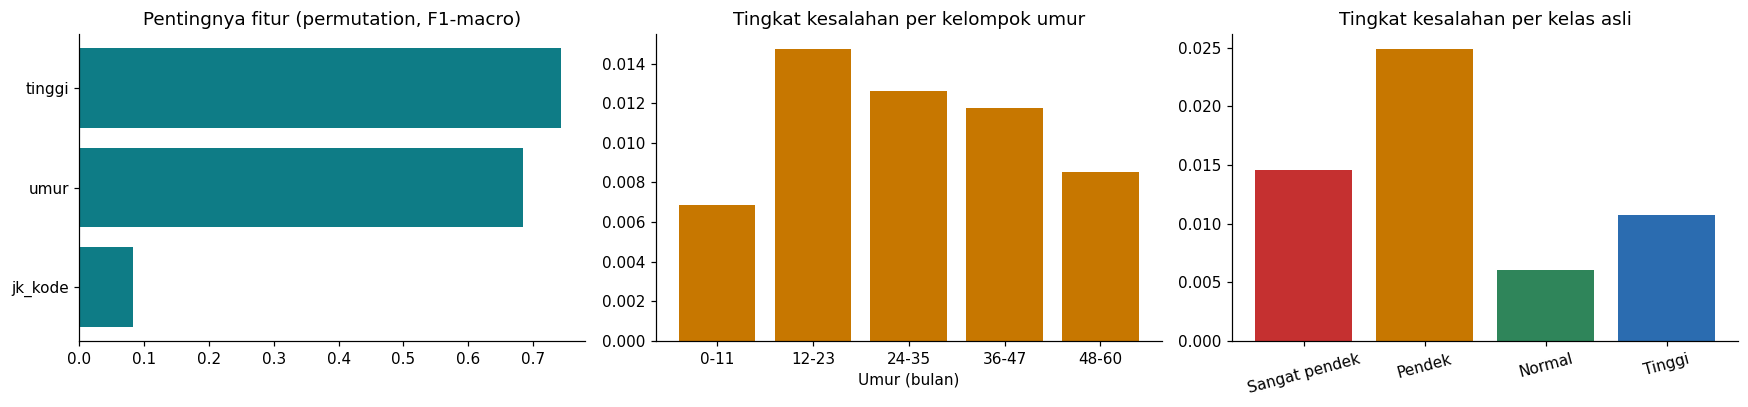

,Penurunan F1-macro saat fitur diacak
tinggi,0.7433
umur,0.6845
jk_kode,0.0827


Tingkat kesalahan per kelompok umur:


kelompok_umur,0-11,12-23,24-35,36-47,48-60
kesalahan,0.0068,0.0148,0.0126,0.0118,0.0085


Tingkat kesalahan per kelas asli:


y,Sangat pendek,Pendek,Normal,Tinggi
kesalahan,0.0146,0.0249,0.006,0.0108


Contoh kasus yang salah diprediksi (diurutkan dari jarak terdekat ke ambang):


,umur,jk,tinggi,z,label,pred,jarak_ke_ambang
31783,49,laki-laki,91.2,-2.999,stunted,severely stunted,0.001
10676,12,laki-laki,71.0,-1.998,stunted,normal,0.002
28731,44,perempuan,92.0,-2.003,stunted,normal,0.003
18908,28,laki-laki,100.3,3.003,normal,tinggi,0.003
21809,32,perempuan,81.3,-3.004,stunted,severely stunted,0.004
10742,12,perempuan,66.3,-2.996,stunted,severely stunted,0.004
25441,39,laki-laki,86.5,-2.996,stunted,severely stunted,0.004
15202,21,laki-laki,76.5,-3.004,stunted,severely stunted,0.004


In [ ]:
from sklearn.inspection import permutation_importance
pi = permutation_importance(best_model, X_te_A, y_te, scoring="f1_macro", n_repeats=5, random_state=SEED, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=FITUR_A).sort_values()

err = df.loc[te_idx].assign(pred=pred, salah=(pred != y_te.values))
per_umur = err.groupby("kelompok_umur", observed=True)["salah"].mean()
per_kelas = err.groupby("y")["salah"].mean().rename(dict(enumerate(NAMA)))

fig, ax = plt.subplots(1, 3, figsize=(16, 3.8))
ax[0].barh(imp.index, imp.values, color="#0E7C86"); ax[0].set_title("Pentingnya fitur (permutation, F1-macro)")
ax[1].bar(per_umur.index.astype(str), per_umur.values, color="#C77700"); ax[1].set_title("Tingkat kesalahan per kelompok umur"); ax[1].set_xlabel("Umur (bulan)")
ax[2].bar(per_kelas.index, per_kelas.values, color=WARNA); ax[2].set_title("Tingkat kesalahan per kelas asli"); ax[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

display(imp.sort_values(ascending=False).to_frame("Penurunan F1-macro saat fitur diacak").round(4))
print("Tingkat kesalahan per kelompok umur:"); display(per_umur.to_frame("kesalahan").round(4).T)
print("Tingkat kesalahan per kelas asli:"); display(per_kelas.to_frame("kesalahan").round(4).T)
print("Contoh kasus yang salah diprediksi (diurutkan dari jarak terdekat ke ambang):")
contoh = err[err["salah"]].assign(jarak_ke_ambang=dz[err["salah"].values]).sort_values("jarak_ke_ambang")
display(contoh[["umur", "jk", "tinggi", "z", "label", "pred", "jarak_ke_ambang"]].assign(
    pred=lambda d: d["pred"].map(dict(enumerate(ORDER)))).head(8).round(3))

Tinggi badan dan umur adalah fitur yang dominan, sesuai dengan cara Z-score dihitung. Jenis kelamin berperan kecil karena selisih kurva
laki-laki dan perempuan kecil. Kesalahan terkonsentrasi pada kasus di sekitar ambang, seperti terlihat pada daftar contoh.

## 15. Simpan model dan contoh penggunaan

Model final dilatih ulang pada seluruh data bersih. Fungsi `prediksi_anak` menggabungkan semuanya: Z-score WHO sebagai rujukan,
prediksi model, tingkat keyakinan, dan penanda zona abu-abu.

In [ ]:
import joblib, sklearn

final_model = clone(best_model).fit(df[FITUR_A], df["y"])
joblib.dump({"model": final_model, "fitur": FITUR_A, "tau": TAU, "kelas": ORDER}, "model.pkl", compress=3)

def prediksi_anak(umur, jk, tinggi, tau=TAU):
    d = pd.DataFrame({"umur": [umur], "jk": [jk], "tinggi": [tinggi]})
    d["jk_kode"] = d["jk"].map(JK_KODE)
    z = tambah_who(d)["z"].iloc[0]
    p = final_model.predict_proba(d[FITUR_A])[0]
    return {"umur": umur, "jk": jk, "tinggi": tinggi, "Z-score WHO": round(float(z), 2),
            "Status WHO": NAMA[int(kelas_dari_z(np.array([z]))[0])],
            "Prediksi model": NAMA[int(p.argmax())], "Keyakinan": round(float(p.max()), 3),
            "Zona abu-abu (ukur ulang)": bool(p.max() < tau)}

contoh = [prediksi_anak(18, "laki-laki", 78.0),  prediksi_anak(30, "perempuan", 80.0),
          prediksi_anak(36, "laki-laki", 85.0),  prediksi_anak(12, "perempuan", 72.5)]
display(pd.DataFrame(contoh))

# Contoh zona abu-abu: kasus data uji dengan keyakinan terendah. Model (best_model) dilatih tanpa data uji,
# jadi keyakinannya jujur. Kasus yang diambil persis dari dataset latih akan selalu 'yakin' karena KNN mengingatnya.
rendah = np.argsort(conf)[:6]
abu_contoh = df.loc[te_idx].iloc[rendah][['umur', 'jk', 'tinggi', 'z']].copy()
abu_contoh['Status WHO'] = [NAMA[k] for k in df.loc[te_idx].iloc[rendah]['y_who']]
abu_contoh['Prediksi model'] = [NAMA[k] for k in pred[rendah]]
abu_contoh['Keyakinan'] = conf[rendah]
abu_contoh['Zona abu-abu'] = abu_contoh['Keyakinan'] < TAU
print('\nKasus data uji dengan keyakinan terendah (contoh zona abu-abu):')
display(abu_contoh.round(3))

metrik = {
    "model_terbaik": best_name,
    "cv_f1_macro": {n: float(v) for n, v in hasil_A["F1-macro"].items()},
    "uji": {n: {k: float(v) for k, v in r.items()} for n, r in hasil_uji.iterrows()},
    "ordinal_vs_multikelas": {n: {k: float(v) for k, v in r.items()} for n, r in banding_ord.iterrows()},
    "data": {"baris_awal": int(n_awal), "baris_unik": int(len(df)), "duplikat_dibuang": int(n_awal - len(df))},
    "cocok_dengan_who": float(cocok), "baris_z_tak_wajar": tak_wajar, "tau_zona_abu": TAU,
    "versi_sklearn": sklearn.__version__,
}
json.dump(metrik, open("metrics.json", "w"), indent=2)
print("Tersimpan: model.pkl dan metrics.json | versi scikit-learn:", sklearn.__version__)
try:
    from google.colab import files
    files.download("model.pkl"); files.download("metrics.json")
except Exception:
    pass

,umur,jk,tinggi,Z-score WHO,Status WHO,Prediksi model,Keyakinan,Zona abu-abu (ukur ulang)
0,18,laki-laki,78.0,-1.58,Normal,Normal,1.0,False
1,30,perempuan,80.0,-3.03,Sangat pendek,Sangat pendek,1.0,False
2,36,laki-laki,85.0,-2.99,Pendek,Pendek,1.0,False
3,12,perempuan,72.5,-0.59,Normal,Normal,1.0,False



Kasus data uji dengan keyakinan terendah (contoh zona abu-abu):


,umur,jk,tinggi,z,Status WHO,Prediksi model,Keyakinan,Zona abu-abu
7438,5,perempuan,70.7,3.008,Tinggi,Tinggi,0.505,True
12990,17,laki-laki,73.2,-3.048,Sangat pendek,Pendek,0.505,True
9732,10,laki-laki,68.9,-1.917,Normal,Normal,0.508,True
37860,58,perempuan,99.1,-1.977,Normal,Pendek,0.512,True
12548,16,laki-laki,74.9,-2.055,Pendek,Pendek,0.523,True
27207,42,laki-laki,111.6,2.963,Normal,Normal,0.526,True


Tersimpan: model.pkl dan metrics.json | versi scikit-learn: 1.8.0


## 16. Kesimpulan

In [ ]:
a = hasil_A["F1-macro"]
u = hasil_uji.loc[best_name]
abu = tabel_abu.loc[0.8]
print("RINGKASAN HASIL (dihitung otomatis dari sel-sel di atas)")
print(f"- Data: {n_awal:,} baris -> {len(df):,} unik. Label cocok dengan Z-score WHO: {cocok:.2%}. Baris |Z| > 6: {tak_wajar:,}.")
print("- F1-macro CV 5-fold (Set A): " + ", ".join(f"{k} {v:.3f}" for k, v in a.sort_values(ascending=False).items()))
print(f"- Model terbaik: {best_name}. Data uji: akurasi {u['Akurasi']:.4f}, F1-macro {u['F1-macro']:.4f}, QWK {u['QWK']:.4f}, kesalahan >= 2 tingkat: {int(u['Salah >= 2 tingkat'])}.")
print(f"- Inovasi 1 (fitur WHO): F1-macro Logistic Regression {banding.loc['Logistic Regression', 'F1-macro Set A']:.3f} -> {banding.loc['Logistic Regression', 'F1-macro Set B']:.3f}.")
print(f"- Inovasi 3 (zona abu-abu, tau = 0,8): {abu['Kasus ditandai abu-abu']:.1%} kasus ditandai, akurasi kasus dijawab {abu['Akurasi kasus dijawab']:.4f}, "
      f"{abu['Kesalahan tertangkap']:.1%} kesalahan tertangkap.")
print(f"- Inovasi 4 (galat ukur): akurasi {tabel_noise['Model standar'].iloc[0]:.3f} (sigma 0) -> {tabel_noise.loc[1.0, 'Model standar']:.3f} (sigma 1 cm).")

RINGKASAN HASIL (dihitung otomatis dari sel-sel di atas)
- Data: 120,999 baris -> 39,425 unik. Label cocok dengan Z-score WHO: 99.51%. Baris |Z| > 6: 938.
- F1-macro CV 5-fold (Set A): KNN 0.985, Random Forest 0.982, Gradient Boosting 0.972, Decision Tree 0.925, Logistic Regression 0.549
- Model terbaik: KNN. Data uji: akurasi 0.9896, F1-macro 0.9855, QWK 0.9941, kesalahan >= 2 tingkat: 0.
- Inovasi 1 (fitur WHO): F1-macro Logistic Regression 0.549 -> 0.987.
- Inovasi 3 (zona abu-abu, tau = 0,8): 3.7% kasus ditandai, akurasi kasus dijawab 0.9996, 96.3% kesalahan tertangkap.
- Inovasi 4 (galat ukur): akurasi 0.990 (sigma 0) -> 0.921 (sigma 1 cm).


**Kontribusi (inovasi)**
1. *Fitur berbasis WHO* membuat model sederhana setara model kompleks, menunjukkan nilai pengetahuan domain.
2. *Klasifikasi ordinal* diuji dengan metrik peka-urutan. Pada data ini tidak memberi keuntungan terukur, dan itu dilaporkan apa adanya.
3. *Zona abu-abu* (ambang keyakinan dan conformal prediction) mengubah probabilitas model menjadi keputusan "ukur ulang" yang menangkap sebagian besar kesalahan.
4. *Uji ketahanan* menunjukkan batas yang ditentukan galat pengukuran, bukan algoritma.

**Keterbatasan yang perlu diingat**
- Karena label dibuat dari rumus WHO, akurasi tinggi tidak membuktikan model "menemukan" sesuatu. Rujukan utama tetap Z-score WHO, dan model berfungsi sebagai pembanding serta penanda ketidakpastian.
- Data hasil simulasi belum mewakili pengukuran lapangan yang berisik. Validasi pada data posyandu sungguhan diperlukan sebelum dipakai nyata.
- Label dataset paling sering menyimpang dari WHO pada umur 24 bulan, dan selisih ukur berbaring vs berdiri (sekitar 0,7 cm) tidak dikoreksi.
- Ini alat bantu skrining, bukan diagnosis medis.

**Langkah berikutnya**: membuat aplikasi web yang memakai `model.pkl` dan fungsi `prediksi_anak`.